In [13]:
import pandas as pd
from aeon.visualisation import plot_critical_difference

/home/gabrielcmerlin/miniconda3/envs/research/lib/python3.12/site-packages/aeon/base/__init__.py:24: FutureWarning: The aeon package will soon be releasing v1.0.0 with the removal of legacy modules and interfaces such as BaseTransformer and BaseForecaster. This will contain breaking changes. See aeon-toolkit.org for more information. Set aeon.AEON_DEPRECATION_WARNING or the AEON_DEPRECATION_WARNING environmental variable to 'False' to disable this warning.
  warnings.warn(


In [15]:
metrics = pd.read_json('znorm_results.json')

cols = ['FCN_biggerKernels','FCN_moreKernels','FCN_moreLayers','FCN']
metrics = metrics[metrics['znorm'] == True].drop('znorm', axis=1)
metrics = metrics[~metrics['model'].str.contains('_do')]
metrics = metrics.drop(['mae_final','std_mae','mse_final','std_mse','time_final','std_time','std_rmse'], axis=1)
metrics

,dataset,model,rmse_final
120,PPGDalia,FCN_biggerKernels,10.333375
122,PPGDalia,FCN_moreLayers,8.765480
124,PPGDalia,FCN,11.340108
125,PPGDalia,FCN_moreKernels,10.460356
128,AustraliaRainfall,FCN_biggerKernels,12.934301
130,AustraliaRainfall,FCN_moreLayers,12.995498
132,AustraliaRainfall,FCN,12.937703
133,AustraliaRainfall,FCN_moreKernels,12.949048
136,NewsHeadlineSentiment,FCN_biggerKernels,0.141758
138,NewsHeadlineSentiment,FCN_moreLayers,0.141754


In [17]:
df_pivot = (
    metrics
    .pivot(index="dataset", columns="model", values="rmse_final")
    .sort_index()
)

df_pivot

model,FCN,FCN_biggerKernels,FCN_moreKernels,FCN_moreLayers
dataset,,,,
AppliancesEnergy,3.189399,3.008833,3.097227,3.189597
AustraliaRainfall,12.937703,12.934301,12.949048,12.995498
BeijingPM10Quality,79.708070,78.431629,78.220329,75.161112
BeijingPM25Quality,57.095611,55.372159,56.140242,51.749446
BenzeneConcentration,0.829511,0.660782,0.794573,0.494966
Covid3Month,0.046992,0.044992,0.045913,0.045981
FloodModeling1,0.017355,0.017231,0.017186,0.017282
FloodModeling2,0.010182,0.010689,0.009630,0.010227
HouseholdPowerConsumption1,161.173285,158.252179,162.631739,162.495515


(<Figure size 600x230 with 1 Axes>, <Axes: >)

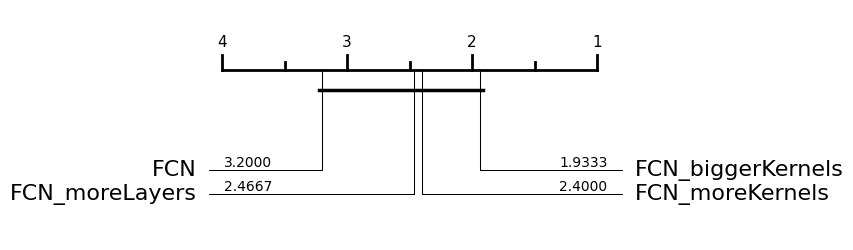

In [18]:
plot_critical_difference(
    df_pivot.values,
    df_pivot.columns.tolist(),
    test='nemenyi',
    lower_better=True,
    alpha=0.05
)